# 예지 보전 기반 설비 고장 예측

In [1]:
import os, hds
import numpy as np
import pandas as pd
from plt_rcs import *

In [25]:
plt.rc(group='figure', figsize=(4, 4))

In [2]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/code/ml_part2'

In [3]:
os.chdir('../../data')

In [4]:
[i for i in os.listdir() if 'pkl' in i]

['Diabetes.pkl',
 'Facility_Sensor_Raw.pkl',
 'Used_Cars_Prep.pkl',
 'Facility_Sensor_Out.pkl',
 'Used_Cars.pkl',
 'Encar_Merged_Prep_20220711.pkl',
 'WhiteWine.pkl',
 'Cereal.pkl',
 'Bank_Customer.pkl',
 'Marine_Product.pkl',
 'APT_Price.pkl']

In [5]:
objs = pd.read_pickle('Facility_Sensor_Out.pkl')

In [6]:
globals().update(objs)

In [7]:
%whos

Variable   Type         Data/Info
---------------------------------
X_train    DataFrame    Shape: (8000, 12)
X_valid    DataFrame    Shape: (2000, 12)
hds        module       <module 'hds' from '/opt/<...>ackages/hds/__init__.py'>
np         module       <module 'numpy' from '/op<...>kages/numpy/__init__.py'>
objs       dict         n=4
os         module       <module 'os' (frozen)>
pd         module       <module 'pandas' from '/o<...>ages/pandas/__init__.py'>
plt        module       <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
sns        module       <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>
y_train    Series       Shape: (8000,)
y_valid    Series       Shape: (2000,)


In [8]:
X_train, X_valid, y_train, y_valid = X_train, X_valid, y_train, y_valid

## XGBoost 분류 모델 학습

In [9]:
from xgboost import XGBClassifier

In [10]:
# XGBoost 분류 모델 생성
model = XGBClassifier(n_estimators=1000, early_stopping_rounds=50)

In [11]:
# 훈련셋으로 모델 학습
model.fit(X=X_train, y=y_train, eval_set=[(X_valid, y_valid)], verbose=False)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,None


In [12]:
# 훈련셋 정확도 확인
model.score(X=X_train, y=y_train)

0.996875

In [13]:
# 검증셋 정확도 확인
model.score(X=X_valid, y=y_valid)

0.9835

In [ ]:
# 특성 중요도 확인
pd.Series(data=model.feature_importances_, index=model.feature_names_in_).sort_values(ascending=False)
# aed_score    0.178011
# spe_score    0.172294
# RotSpd       0.125475
# AirTmp       0.121684
# ToolWear     0.110775
# ht2_score    0.072484
# Torque       0.052223
# Type         0.046746
# mnd_score    0.044899
# iso_score    0.026432
# ocs_score    0.024980
# ProcTmp      0.023997
# dtype: float32

aed_score    0.178011
spe_score    0.172294
RotSpd       0.125475
AirTmp       0.121684
ToolWear     0.110775
ht2_score    0.072484
Torque       0.052223
Type         0.046746
mnd_score    0.044899
iso_score    0.026432
ocs_score    0.024980
ProcTmp      0.023997
dtype: float32

In [16]:
model.get_booster().num_boosted_rounds()

72

In [17]:
model.best_iteration

21

In [18]:
model.best_score

0.05834670398417074

## 분류 모델 성능 평가

In [20]:
# 검증셋 예측값 생성
y_pred = model.predict(X=X_valid)

In [21]:
# 성능 지표 확인
hds.stat.clfmetrics(y_true=y_valid, y_pred=y_pred)

## ROC PR 곡선 시각화

In [ ]:
# 예측 확률 생성
y_prob = model.predict_proba(X=X_valid)

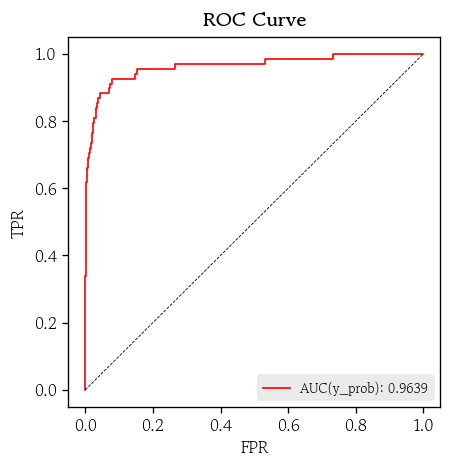

In [26]:
hds.plot.roc_curve(y_true=y_valid, y_prob=y_prob, color='red')

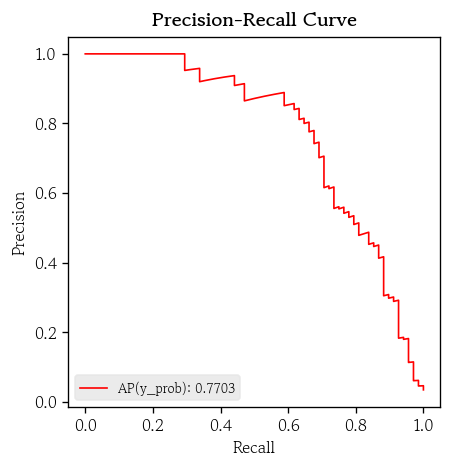

In [27]:
hds.plot.pr_curve(y_true=y_valid, y_prob=y_prob, color='red')

## 순열 중요도 확인

In [28]:
from sklearn.inspection import permutation_importance

In [29]:
# 순열 중요도 생성
pi = permutation_importance(estimator=model, X=X_valid, y=y_valid, random_state=0, scoring='roc_auc')

In [ ]:
# 특성별 순열 중요도 평균 확인
pd.Series(data=pi['importances_mean'], index=model.feature_names_in_).sort_values(ascending=False)
# ToolWear     0.075433
# RotSpd       0.040325
# AirTmp       0.037343
# spe_score    0.031216
# Torque       0.024404
# iso_score    0.004902
# ht2_score    0.004299
# ProcTmp      0.003378
# aed_score    0.003056
# mnd_score    0.001787
# ocs_score   -0.000309
# Type        -0.000782
# dtype: float64

ToolWear     0.075433
RotSpd       0.040325
AirTmp       0.037343
spe_score    0.031216
Torque       0.024404
iso_score    0.004902
ht2_score    0.004299
ProcTmp      0.003378
aed_score    0.003056
mnd_score    0.001787
ocs_score   -0.000309
Type        -0.000782
dtype: float64

## 단변량 PDP 시각화

In [31]:
from sklearn.inspection import PartialDependenceDisplay

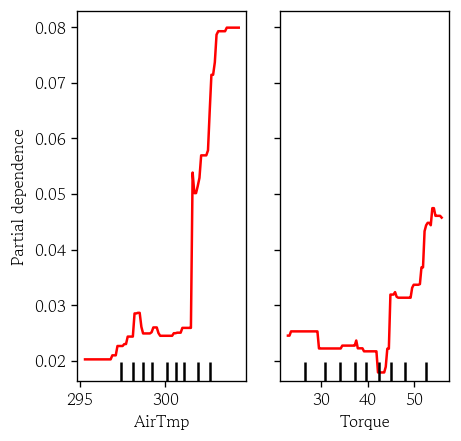

In [33]:
PartialDependenceDisplay.from_estimator(
    estimator=model, X=X_valid,
    features=['AirTmp', 'Torque'],
    line_kw={
        'color': 'red',
        'linewidth': 1.5
    }
)
plt.show()

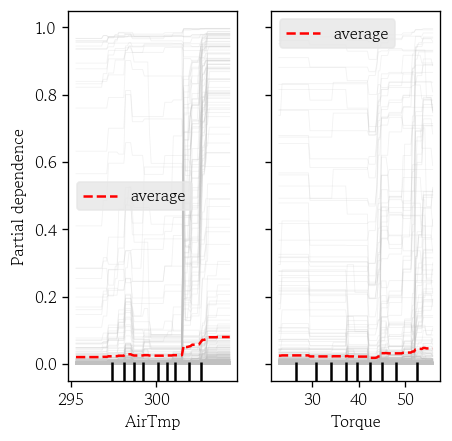

In [35]:
# ICE 곡선 추가
PartialDependenceDisplay.from_estimator(
    estimator=model, X=X_valid,
    features=['AirTmp', 'Torque'],
    kind='both',
    random_state=0,
    pd_line_kw={
        'color': 'red',
        'linewidth': 1.5
    },
    ice_lines_kw={
        'color': 'silver',
        'alpha': 0.2
    }
)
plt.show()

## 이변량 PDP 시각화

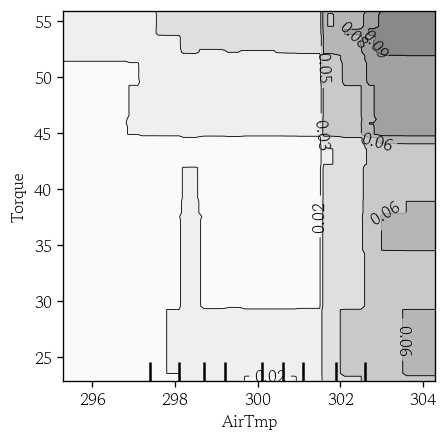

In [37]:
PartialDependenceDisplay.from_estimator(
    estimator=model, X=X_valid,
    features=[['AirTmp', 'Torque']],
    random_state=0,
    contour_kw={
        'cmap': 'Greys',
        'alpha': 0.5
    }
)
plt.show()

## LIME 설명기 생성

In [38]:
from lime.lime_tabular import LimeTabularExplainer

In [39]:
# 훈련셋 분포를 이용하여 설명을 생성하는 설명기 생성
lime_explainer = LimeTabularExplainer(
    training_data=X_train.values, 
    feature_names=model.feature_names_in_,
    mode='classification',
    class_names=['정상(0)', '고장(1)'],
    discretize_continuous=True,
    random_state=0
)

In [40]:
# 검증셋 예측 확률이 최댓값인 인덱스 설정
index = np.argsort(y_prob[:, 1])[-1]

In [42]:
# 검증셋의 특정 샘플에 대해 LIME 국소 설명 생성
lime_exp = lime_explainer.explain_instance(
    data_row=X_valid.values[index],
    predict_fn=model.predict_proba,
    num_features=5
)

In [43]:
from IPython.display import HTML, display

In [44]:
# LIME 국소 설명 결과를 HTML 파일로 저장
lime_exp.save_to_file('LIME_Explanation_Fail.html')

In [45]:
# HTML 파일 렌더링
display(HTML('LIME_Explanation_Fail.html'))

## SHAP 설명기 생성

In [46]:
import shap

In [47]:
# 훈련셋 배경으로 SHAP 설명기 생성
shap_explainer = shap.TreeExplainer(model=model, data=X_train, model_output='probability')

In [ ]:
# 검증셋의 SHAP 값 계산
shap_values = shap_explainer.shap_values(X=X_valid, check_additivity=False)

In [49]:
# 차원별 크기 확인
shap_values.shape

(2000, 12)

In [50]:
# 고장 클래스를 선택하여 데이터프레임으로 변환
shap_1 = pd.DataFrame(data=shap_values, columns=model.feature_names_in_)

In [ ]:
# 특성별 SHAP 값의 절대값 평균 확인
shap_1.abs().mean().sort_values(ascending=False)
# RotSpd       0.009619
# ToolWear     0.008806
# spe_score    0.008355
# AirTmp       0.007499
# Torque       0.005064
# aed_score    0.004951
# mnd_score    0.002389
# ht2_score    0.001944
# ProcTmp      0.001572
# Type         0.001410
# iso_score    0.001218
# ocs_score    0.000974
# dtype: float64

RotSpd       0.009619
ToolWear     0.008806
spe_score    0.008355
AirTmp       0.007499
Torque       0.005064
aed_score    0.004951
mnd_score    0.002389
ht2_score    0.001944
ProcTmp      0.001572
Type         0.001410
iso_score    0.001218
ocs_score    0.000974
dtype: float64

## SHAP 특성 중요도 시각화

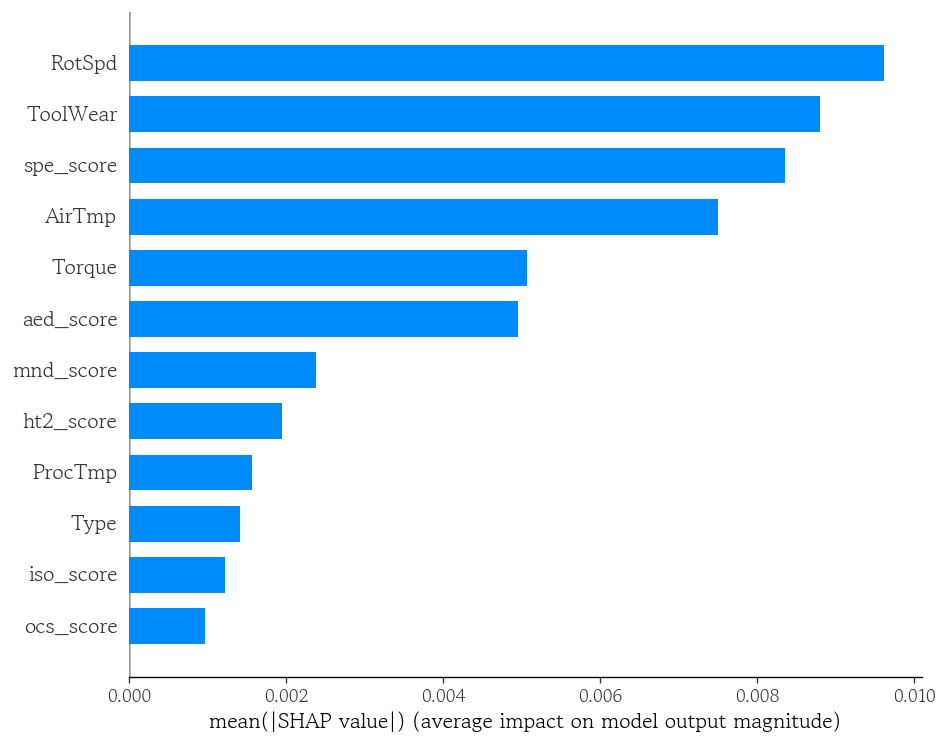

In [52]:
shap.summary_plot(
    shap_values=shap_1.values,
    features=X_valid,
    plot_type='bar'
)

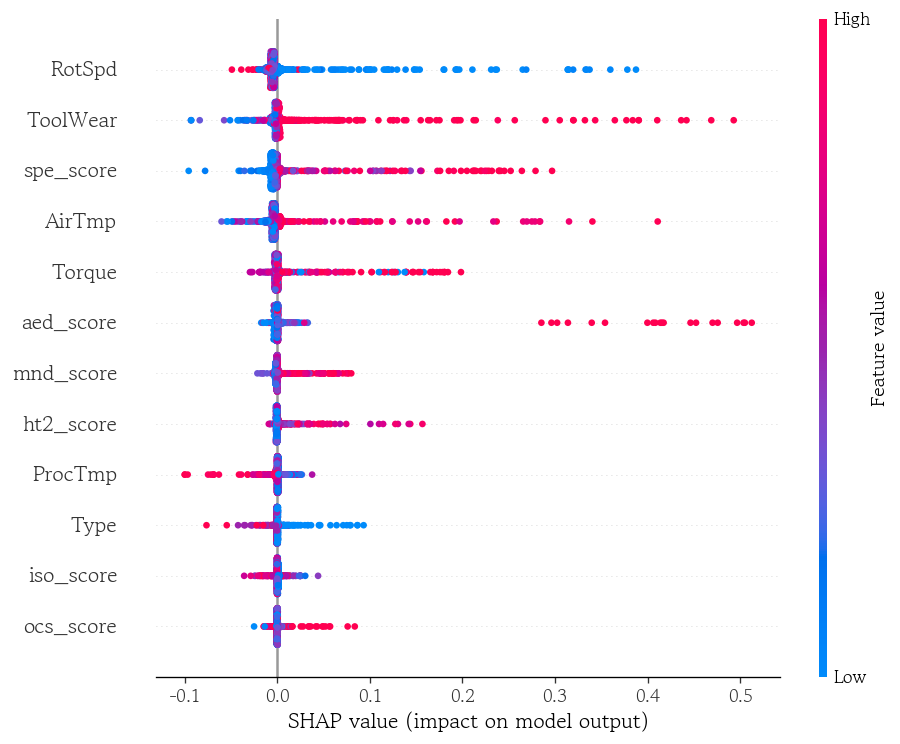

In [53]:
shap.summary_plot(
    shap_values=shap_1.values,
    features=X_valid,
    plot_type='dot'
)

## SHAP 의존도 플랏 시각화

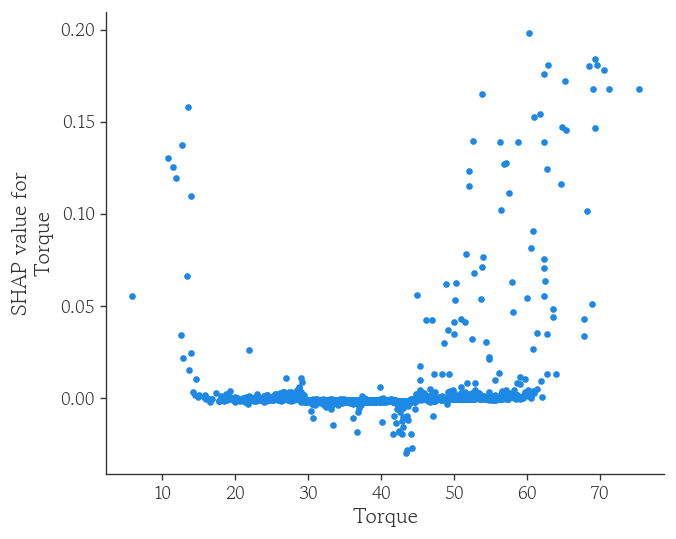

In [54]:
shap.dependence_plot(
    ind='Torque',
    shap_values=shap_1.values,
    features=X_valid,
    interaction_index=None
)

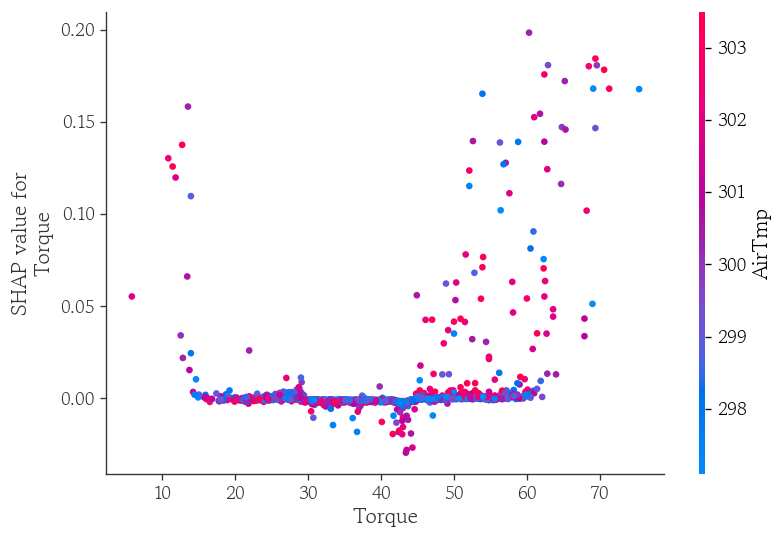

In [55]:
shap.dependence_plot(
    ind='Torque',
    shap_values=shap_1.values,
    features=X_valid,
    interaction_index='AirTmp'
)

## 국소 샘플의 SHAP 기여도 확인

In [58]:
# 이탈 확률의 기댓값 할당
base_value = shap_explainer.expected_value

In [ ]:
# 검증셋에서 고장 확률이 가장 높은 샘플의 SHAP 값 확인
pd.Series(data=shap_1.values[index, :], index=model.feature_names_in_).sort_values(ascending=False)
# aed_score    0.353966
# ToolWear     0.193821
# Torque       0.154404
# spe_score    0.106423
# mnd_score    0.070605
# Type         0.044976
# ht2_score    0.035313
# RotSpd       0.017267
# ProcTmp      0.006046
# ocs_score    0.004642
# AirTmp      -0.002052
# iso_score   -0.002083
# dtype: float64

aed_score    0.353966
ToolWear     0.193821
Torque       0.154404
spe_score    0.106423
mnd_score    0.070605
Type         0.044976
ht2_score    0.035313
RotSpd       0.017267
ProcTmp      0.006046
ocs_score    0.004642
AirTmp      -0.002052
iso_score   -0.002083
dtype: float64

## 국소 샘플의 SHAP 기여도 누적 플랏 시각화 결과

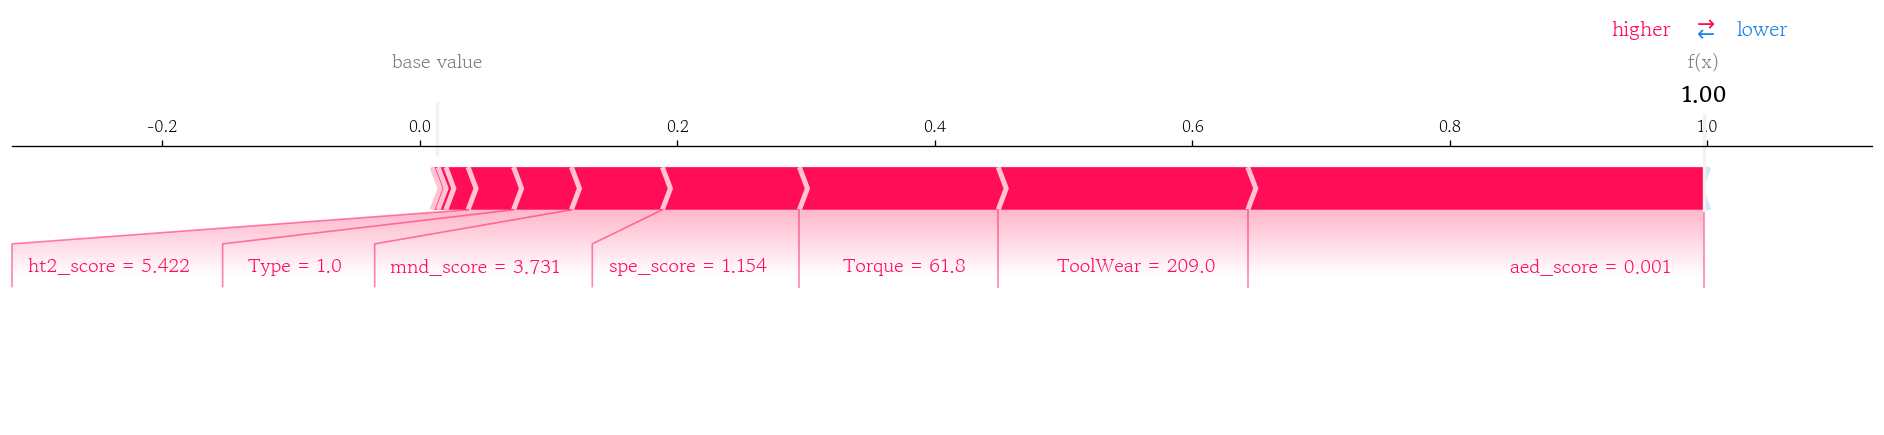

In [64]:
shap.force_plot(
    base_value=base_value, 
    shap_values=shap_1.values[index, :], 
    features=X_valid.iloc[index, :].round(3),
    matplotlib=True
)